In [ ]:
import nest
import matplotlib.pyplot as plt
import numpy as np

nest.ResetKernel()

In [ ]:
rate_desiderato = 80.0 # Hz che arriveranno ai neuroni
correlazione_c = 0.1

# Calcolo del rate del processo madre
rate_madre = rate_desiderato / correlazione_c # Sarà 400.0 Hz

In [ ]:
parrot_pop = nest.Create("parrot_neuron", 10)

pop1 = nest.Create("iaf_psc_exp", 10)

sr_mip = nest.Create("spike_recorder")

sr_parrot = nest.Create("spike_recorder")

sr_neurons = nest.Create("spike_recorder")

mip_gen = nest.Create("mip_generator", params={"rate": rate_madre, "p_copy": correlazione_c})

vm = nest.Create("voltmeter")

In [ ]:
nest.Connect(mip_gen, parrot_pop)

nest.Connect(mip_gen, sr_mip)

nest.Connect(parrot_pop, sr_parrot)

nest.Connect(parrot_pop, pop1, conn_spec={"rule": "one_to_one"}, syn_spec={"synapse_model": "static_synapse", "weight": 1500.0})

nest.Connect(pop1, sr_neurons)

nest.Connect(vm, pop1[0])

In [ ]:
nest.Simulate(1000.0)

[INFO] [2026-05-06 19:21:41] Preparing 25 nodes for simulation.
[INFO] [2026-05-06 19:21:41] Number of local nodes: 25
Simulation time (ms): 1000
Number of OpenMP threads: 1
Not using MPI
[INFO] [2026-05-06 19:21:41] Simulation finished.


In [ ]:
eventi_mip = nest.GetStatus(sr_mip, "events")[0]
time_mip = eventi_mip["times"]
senders_mip = eventi_mip["senders"]

spike0_times_mip = eventi_mip["times"][eventi_mip["senders"] == 1]

eventi_parrot = nest.GetStatus(sr_parrot, "events")[0]
time_parrot = eventi_parrot["times"]
senders_parrot = eventi_parrot["senders"]

eventi_neurons = nest.GetStatus(sr_neurons, "events")[0]
time_neurons = eventi_neurons["times"]
senders_neurons = eventi_neurons["senders"] # Per allineare gli ID dei neuroni con quelli del parrot

spike0_times = eventi_neurons["times"][eventi_neurons["senders"] == 11]

eventi_vm = nest.GetStatus(vm, "events")[0]
time_vm = eventi_vm["times"]
voltage_vm = eventi_vm["V_m"]

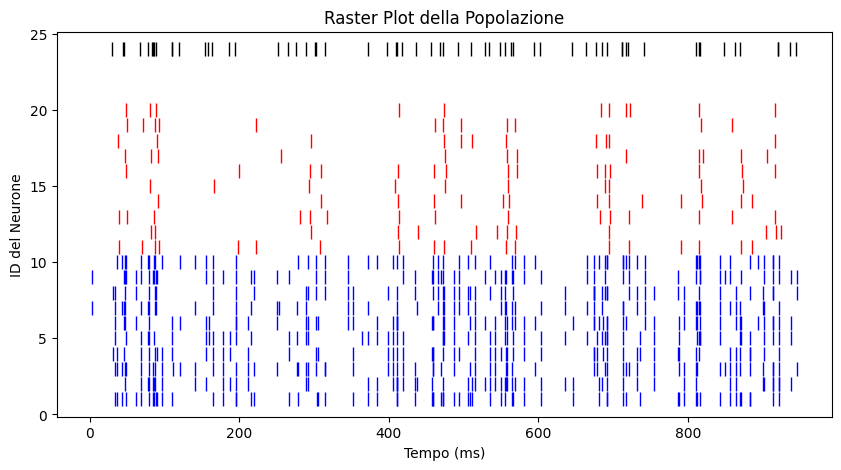

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(time_mip, senders_mip, '|', color='black', markersize=10)
plt.plot(time_neurons, senders_neurons, '|', color='red', markersize=10)
plt.plot(time_parrot, senders_parrot, '|', color='blue', markersize=10)
plt.xlabel("Tempo (ms)")
plt.ylabel("ID del Neurone")
plt.title("Raster Plot della Popolazione")
plt.show()

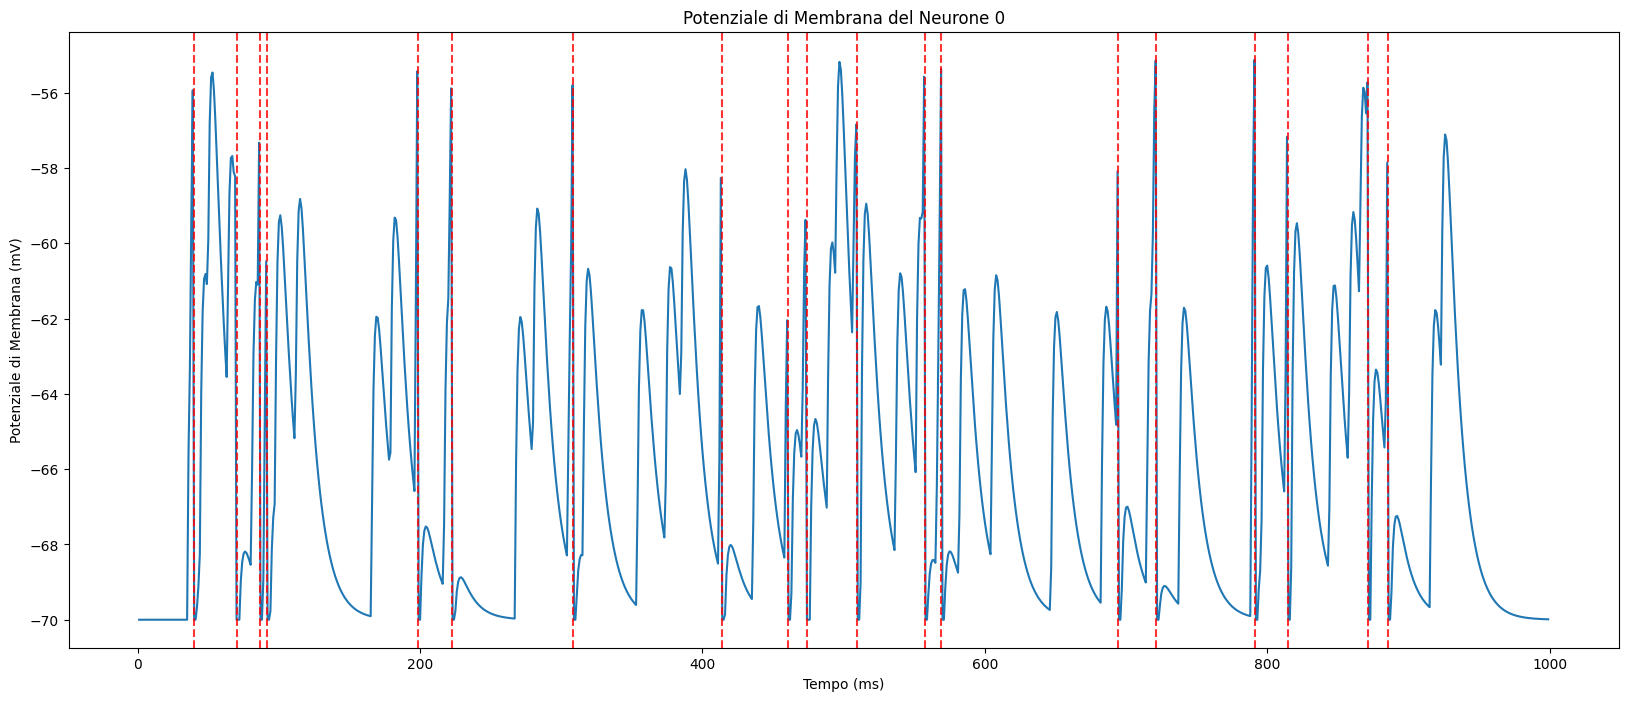

In [ ]:
plt.figure(figsize=(20, 8))
plt.plot(time_vm, voltage_vm)
for i in range(np.size(spike0_times)):
    plt.axvline(x=spike0_times[i], color='red', linestyle='--', alpha=0.8)
for i in range(np.size(spike0_times_mip)):
    plt.axvline(x=spike0_times_mip[i], color='black', linestyle='--', alpha=0.2)
plt.xlabel("Tempo (ms)")
plt.ylabel("Potenziale di Membrana (mV)")
plt.title("Potenziale di Membrana del Neurone 0")
plt.show()